# 02 — Data Analysis Report (Deliverable B)

All tasks B1.1–B4.3 on cleaned `master_train.csv`.

Run the script for a full markdown report:
```bash
python src/analysis.py
```
Output: `reports/B_analysis_report.md`

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.analysis import run_all, write_report, export_tables, load_master

results = run_all()
write_report(results, ROOT / 'reports' / 'B_analysis_report.md')
export_tables(results, ROOT / 'reports' / 'B_tables')
print('Zone types:', results['zone_types'])

Zone types: {'Arat Kilo': 'transport_hub', 'Ayat': 'residential_late_launch', 'Bole': 'market', 'CMC': 'residential', 'Gerji': 'residential', 'Kazanchis': 'transport_hub', 'Kolfe': 'residential', 'Lideta': 'transport_hub', 'Megenagna': 'transport_hub', 'Merkato': 'market', 'Piassa': 'transport_hub', 'Sarbet': 'residential'}


## B1 — Demand patterns

### B1.1 Volume by zone

In [2]:
display(results['B1.1'])
print('Top zone carries most demand; Ayat has fewer hours (late launch) — compare means carefully.')

,zone,total_trips,mean_trips_per_hour,n_hours,first_hour,last_hour,share_pct
0,Merkato,286366.0,40.619291,7050,2025-01-01,2025-10-31 23:00:00,12.045030
1,Bole,278810.0,39.407774,7075,2025-01-01,2025-10-31 23:00:00,11.727212
2,Megenagna,271694.0,38.467224,7063,2025-01-01,2025-10-31 23:00:00,11.427901
3,Kazanchis,225140.0,31.848918,7069,2025-01-01,2025-10-31 23:00:00,9.469762
4,Piassa,200354.0,28.322590,7074,2025-01-01,2025-10-31 23:00:00,8.427222
5,Lideta,200207.0,28.293810,7076,2025-01-01,2025-10-31 23:00:00,8.421039
6,CMC,183874.0,25.945252,7087,2025-01-01,2025-10-31 23:00:00,7.734046
7,Gerji,171855.0,24.369682,7052,2025-01-01,2025-10-31 23:00:00,7.228507
8,Kolfe,163398.0,23.104921,7072,2025-01-01,2025-10-31 23:00:00,6.872791
9,Sarbet,154095.0,21.820306,7062,2025-01-01,2025-10-31 23:00:00,6.481492


Top zone carries most demand; Ayat has fewer hours (late launch) — compare means carefully.


### B1.2 Hour-of-day profile by zone type

,zone_type,peak_hour,peak_mean_trips,quiet_hour,quiet_mean_trips
0,market,13,65.256532,2,7.444181
1,residential,7,49.095519,2,3.915677
2,residential_late_launch,7,36.337500,2,2.787500
3,transport_hub,18,79.610377,1,5.101887


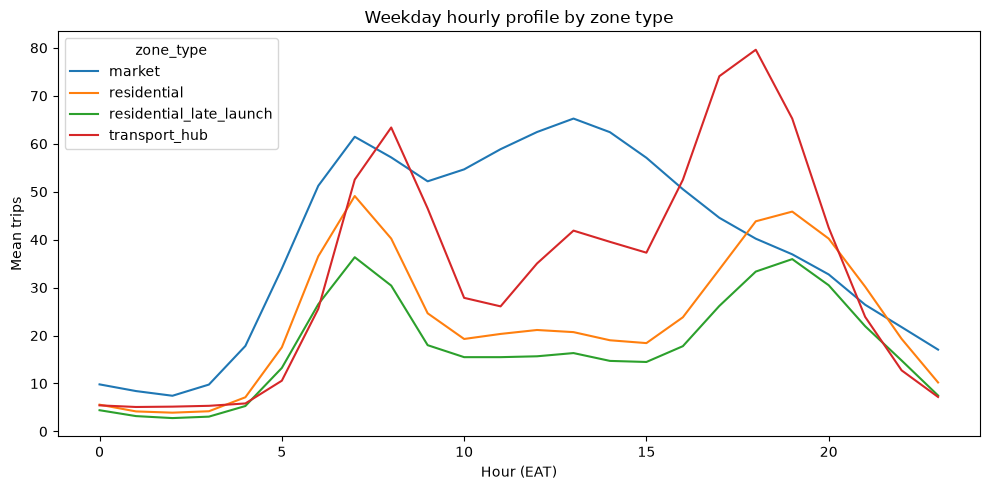

In [3]:
display(results['B1.2'])
df = load_master()
df['zone_type'] = df['zone'].map(results['zone_types'])
wd = df[(df['is_weekend']==0) & df['trips'].notna()]
prof = wd.groupby(['zone_type','hour'])['trips'].mean().unstack('hour')
ax = prof.T.plot(figsize=(10,5), title='Weekday hourly profile by zone type')
ax.set_xlabel('Hour (EAT)'); ax.set_ylabel('Mean trips')
plt.tight_layout(); plt.show()

### B1.3 Weekday vs weekend

is_weekend,zone,weekday_mean,weekend_mean,weekend_to_weekday
0,Bole,36.123938,47.648313,1.319023
1,Gerji,23.812289,25.770802,1.082248
2,Kolfe,22.620186,24.326531,1.075435
3,CMC,25.405443,27.303075,1.074694
4,Sarbet,21.378976,22.936532,1.072855
5,Ayat,17.637990,18.820463,1.067041
6,Merkato,42.059628,36.987512,0.879407
7,Lideta,29.838340,24.417163,0.818315
8,Megenagna,40.604393,33.094527,0.815048
9,Kazanchis,37.043315,18.802285,0.507576


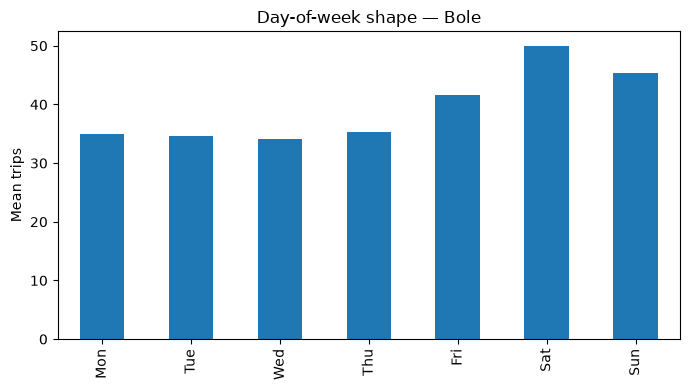

In [4]:
display(results['B1.3'])
standout = results['B1.3'].iloc[0]['zone']
d = df[df['zone']==standout].dropna(subset=['trips'])
dow = d.groupby('dow')['trips'].mean()
dow.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow.plot(kind='bar', title=f'Day-of-week shape — {standout}', figsize=(7,4))
plt.ylabel('Mean trips'); plt.tight_layout(); plt.show()

### B1.4 Trend

{'early_4w_mean': 43109.75, 'late_4w_mean': 55831.25, 'growth_pct_early_to_late': 29.50956570149444, 'daily_mean_jan': 6239.5161290322585, 'daily_mean_oct': 9276.870967741936, 'implication': 'City-wide demand grew over Jan–Oct; a November forecast should allow for level shift / trend (week_index or recent lags), not only seasonal averages.'}


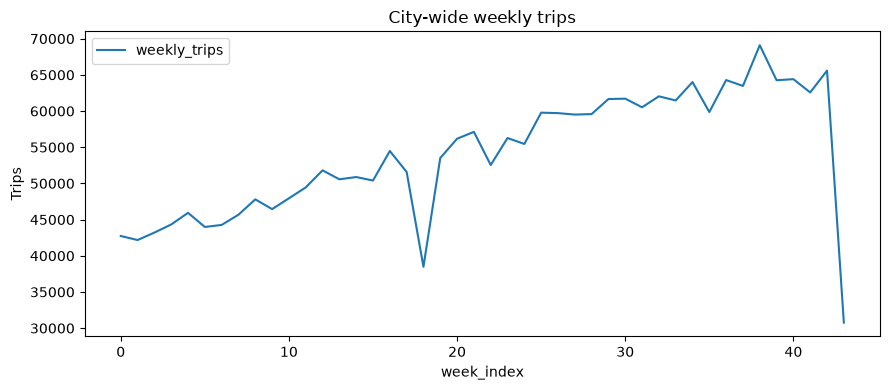

In [5]:
b14 = results['B1.4']
print({k: b14[k] for k in b14 if k != 'weekly'})
b14['weekly'].plot(x='week_index', y='weekly_trips', figsize=(9,4), title='City-wide weekly trips')
plt.ylabel('Trips'); plt.tight_layout(); plt.show()

## B2 — Weather

### B2.1 Timezone check

In [6]:
b21 = results['B2.1']
print('Temp peak hour (EAT):', b21['temp_peak_hour_eat'])
print('Corr shifts:', b21['rain_demand_corr_by_shift_h'])
print('Wrong UTC-as-local corr:', b21['corr_if_utc_treated_as_local'])
print(b21['interpretation'])

Temp peak hour (EAT): 15
Corr shifts: {0: 0.283358119905005, 1: 0.16654744701301674, 2: 0.1465595981471896, 3: 0.10373274821948283, 4: 0.055091207195206764, 5: 0.0007384333061837528}
Wrong UTC-as-local corr: 0.14739279863356755
After UTC→EAT, mean temperature peaks at hour 15 (afternoon local). Rain–demand correlation at shift 0 (correct clock) is 0.2834; treating UTC as local yields 0.1474. Misalignment by 1–5h changes the measured relationship — clocks must match before modeling.


### B2.2 Rain effect by zone type

In [7]:
display(results['B2.2'])
print('Ratio>1 => rainy hours busier than matched dry hours. Rain is not uniform across zone types.')

,zone_type,mean_wet_dry_ratio,median_wet_dry_ratio,n_cells
2,residential_late_launch,1.331330,1.288391,92
3,transport_hub,1.272467,1.271649,465
1,residential,1.256316,1.262607,371
0,market,1.074713,1.043957,186


Ratio>1 => rainy hours busier than matched dry hours. Rain is not uniform across zone types.


### B2.3 Rain dose-response

In [8]:
display(results['B2.3'])
print('Values relative to rain_class=none. Look for saturation from moderate to heavy.')

rain_class,zone_type,none,light,moderate,heavy
0,market,1.0,1.266050,1.304267,1.291552
1,residential,1.0,1.479612,1.747657,2.076568
2,residential_late_launch,1.0,1.498601,1.792087,2.245269
3,transport_hub,1.0,1.728021,2.022459,2.399065


Values relative to rain_class=none. Look for saturation from moderate to heavy.


## B3 — Events & calendar

In [9]:
print('### B3.1 Holidays')
display(results['B3.1'])
display(results['B3.1_zone'])
print('### B3.2 Football windows')
display(results['B3.2'])
print('### B3.3 Event type ranking')
display(results['B3.3'])
print('### B3.4 Cancelled / unlisted')
display(results['B3.4']['cancelled_footprint'])
print(results['B3.4']['unlisted_spikes'])

### B3.1 Holidays


,date,dow,holiday_trips,baseline_trips,index
0,2025-01-07,1,4805.0,6632.000000,0.724517
4,2025-04-18,4,6248.0,8119.500000,0.769506
9,2025-06-06,4,6998.0,8796.000000,0.795589
10,2025-09-04,3,7606.0,9210.200000,0.825824
11,2025-09-11,3,7783.0,9362.000000,0.831339
3,2025-03-31,0,6275.0,7394.833333,0.848565
8,2025-05-28,2,6914.0,8059.666667,0.857852
6,2025-05-01,3,6611.0,7682.166667,0.860565
7,2025-05-05,0,6241.0,6619.333333,0.942844
5,2025-04-20,6,6059.0,6369.666667,0.951227


,zone,holiday_index
0,Merkato,0.522764
1,Arat Kilo,0.531547
2,Piassa,0.560270
3,Kazanchis,0.590631
4,Lideta,0.821405
5,Megenagna,0.851233
6,Sarbet,0.986961
7,CMC,1.003927
8,Gerji,1.009800
9,Ayat,1.011802


### B3.2 Football windows


,window,mean_trips,uplift_vs_baseline
0,baseline_no_event,26.595689,1.000000
1,2h_before,70.469697,2.649666
2,during_window,45.323810,1.704179
3,2h_after,53.985714,2.029867


### B3.3 Event type ranking


,event_type,mean_trips_on,mean_trips_off,effect_ratio,n_on
2,concert,69.850962,28.505477,2.450440,208
1,football_match,54.726141,28.533001,1.917995,241
4,any_event,29.855337,28.113008,1.061976,23655
0,public_holiday,23.834875,28.823072,0.826937,3567
3,road_closure,20.480874,28.644919,0.714992,366


### B3.4 Cancelled / unlisted


,event_id,event_type,zone,mean_on,mean_off,ratio
0,EVT-0113,concert,Bole,33.400000,39.412023,0.847457
1,EVT-0052,football_match,Kazanchis,66.666667,31.834135,2.094188
2,EVT-0058,football_match,Kazanchis,20.000000,31.853948,0.627866
3,EVT-0042,conference,Kazanchis,39.375000,31.840391,1.236637
4,EVT-0099,concert,Bole,32.000000,39.413013,0.811915
5,EVT-0020,football_match,Kazanchis,34.333333,31.847863,1.078042


[{'date': '2025-09-26', 'city_trips': 11497.0, 'top_zone': 'Kazanchis', 'top_zone_trips': 1513.0, 'hypothesis': 'Possible unlisted concert/market peak, payday cluster, or weather-driven surge not tagged as a calendar event.'}, {'date': '2025-09-12', 'city_trips': 11005.0, 'top_zone': 'Megenagna', 'top_zone_trips': 1394.0, 'hypothesis': 'Possible unlisted concert/market peak, payday cluster, or weather-driven surge not tagged as a calendar event.'}, {'date': '2025-10-28', 'city_trips': 10812.0, 'top_zone': 'Megenagna', 'top_zone_trips': 1252.0, 'hypothesis': 'Possible unlisted concert/market peak, payday cluster, or weather-driven surge not tagged as a calendar event.'}]


## B4 — Operations & data quality

In [10]:
print('B4.1', results['B4.1'])
display(results['B4.2']['by_zone'])
print('Late launch:', results['B4.2']['late_launch_zones'])
print(results['B4.2']['treatment'])
print('B4.3', results['B4.3'])

B4.1 {'trips_vs_active_drivers': 0.9667784851455771, 'trips_vs_avg_wait_min': 0.5248234110244324, 'trips_vs_avg_fare_birr': 0.006180928085991325, 'interpretation': 'active_drivers correlates strongly with trips because dispatch follows demand — it is a consequence, not a cause available at forecast time. avg_wait_min often moves with congestion/shortage (can look negative or weak). avg_fare_birr reflects mix/distance more than volume. None of these three may be used as model inputs for November (Rule 6 / D4).'}


,zone,first_hour,last_hour,n_missing_hours,n_gap_periods,longest_gap_hours
9,Merkato,2025-01-01,2025-10-31 23:00:00,108,66,42.0
11,Sarbet,2025-01-01,2025-10-31 23:00:00,107,66,42.0
5,Kazanchis,2025-01-01,2025-10-31 23:00:00,102,61,42.0
3,CMC,2025-01-01,2025-10-31 23:00:00,100,59,42.0
8,Megenagna,2025-01-01,2025-10-31 23:00:00,100,59,42.0
6,Kolfe,2025-01-01,2025-10-31 23:00:00,100,59,42.0
2,Bole,2025-01-01,2025-10-31 23:00:00,100,59,42.0
4,Gerji,2025-01-01,2025-10-31 23:00:00,97,55,42.0
10,Piassa,2025-01-01,2025-10-31 23:00:00,97,55,42.0
0,Arat Kilo,2025-01-01,2025-10-31 23:00:00,95,54,42.0


Late launch: {'Ayat': '2025-03-15'}
Ayat starts later than other zones → late launch (do not impute pre-launch as zeros for training labels; model can still forecast Ayat in November). Short scattered gaps → random missing records (dropped or left out of target). Long multi-zone simultaneous holes → treat as platform outage periods and exclude from training metrics.
B4.3 {'mean_trips_payday': 29.771328162869608, 'mean_trips_other': 28.32091053785399, 'ratio_raw': 1.0512136650082975, 'mean_detrended_payday': 0.4765317359562146, 'mean_detrended_other': -0.11809183113939374, 'keep_as_feature': np.True_, 'interpretation': 'Payday-window mean trips 29.77 vs other 28.32 (ratio 1.051). After weekly detrend, difference is 0.595 trips/hour. Effect is large enough to keep `is_payday_window` as a feature.'}
